# Improting nessary Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report
from tensorflow.keras.applications import ResNet50 
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score

# Load Data

In [2]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

In [3]:
# Get paths for each class within training and testing folders
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
train_data = []
test_data = []

for label in classes:
    train_images = glob(os.path.join(train_dir, label, '*.jpg'))
    test_images = glob(os.path.join(test_dir, label, '*.jpg'))
    
    # Append the paths and corresponding labels to lists
    train_data.extend([(img_path, label) for img_path in train_images])
    test_data.extend([(img_path, label) for img_path in test_images])

# Convert to DataFrame for easier manipulation
train_df = pd.DataFrame(train_data, columns=['image_path', 'label'])
test_df = pd.DataFrame(test_data, columns=['image_path', 'label'])


# EDA(Explore Data Analysis)

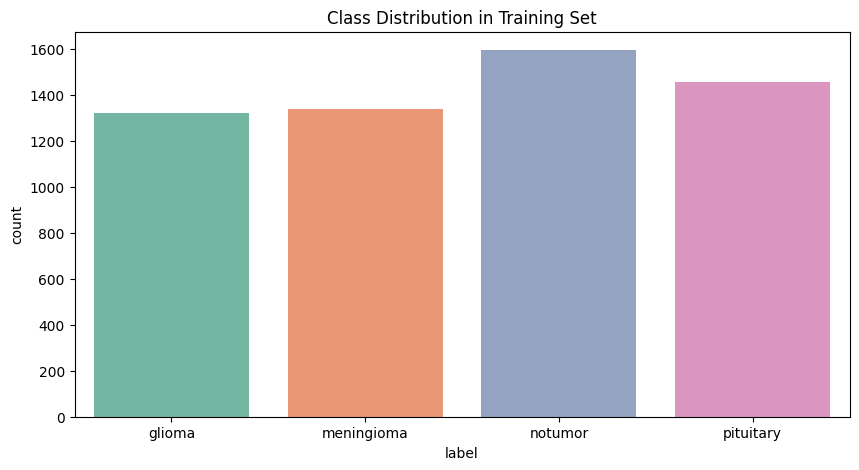

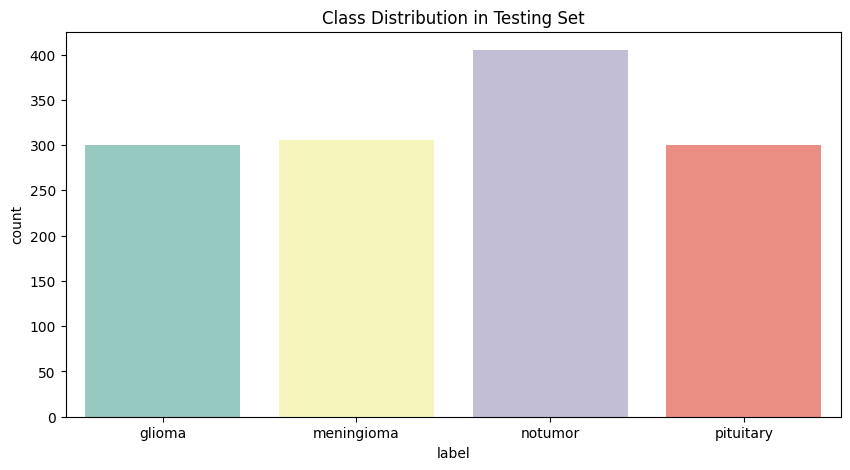

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='label', palette='Set2')
plt.title("Class Distribution in Training Set")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=test_df, x='label', palette='Set3')
plt.title("Class Distribution in Testing Set")
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


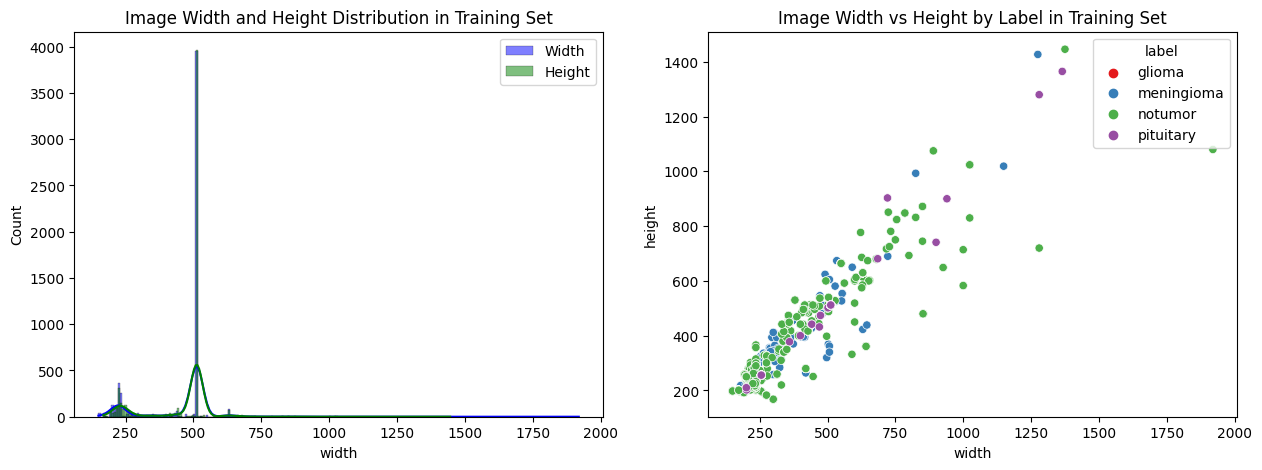

In [5]:
# Collect image dimensions
train_df['image_size'] = train_df['image_path'].apply(lambda x: Image.open(x).size)
test_df['image_size'] = test_df['image_path'].apply(lambda x: Image.open(x).size)

# Separate width and height
train_df['width'], train_df['height'] = zip(*train_df['image_size'])
test_df['width'], test_df['height'] = zip(*test_df['image_size'])

# Plot the distribution of image dimensions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(train_df['width'], kde=True, ax=ax[0], color="blue", label="Width")
sns.histplot(train_df['height'], kde=True, ax=ax[0], color="green", label="Height")
ax[0].set_title("Image Width and Height Distribution in Training Set")
ax[0].legend()

sns.scatterplot(data=train_df, x="width", y="height", hue="label", ax=ax[1], palette="Set1")
ax[1].set_title("Image Width vs Height by Label in Training Set")
plt.show()


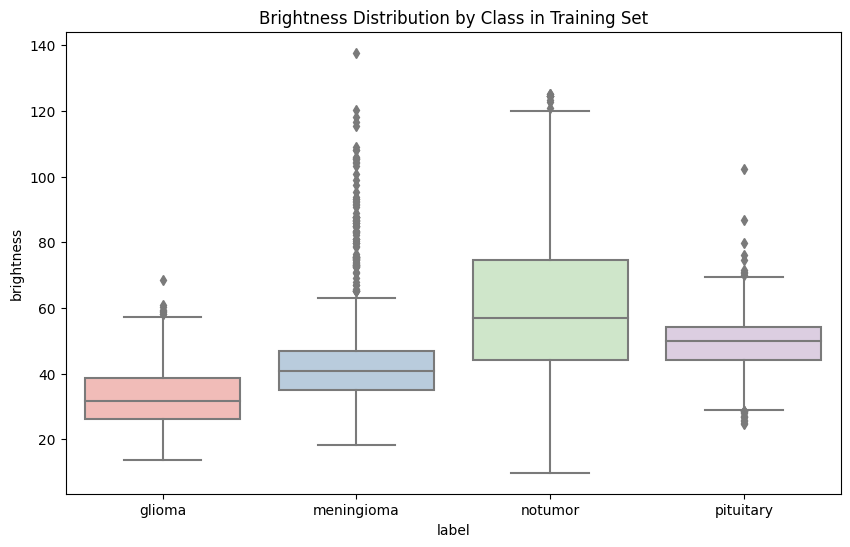

In [6]:

# Calculate mean pixel intensity (brightness) for each image
train_df['brightness'] = train_df['image_path'].apply(lambda x: np.array(Image.open(x)).mean())
test_df['brightness'] = test_df['image_path'].apply(lambda x: np.array(Image.open(x)).mean())

# Plot the brightness distribution by class
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x="label", y="brightness", palette="Pastel1")
plt.title("Brightness Distribution by Class in Training Set")
plt.show()

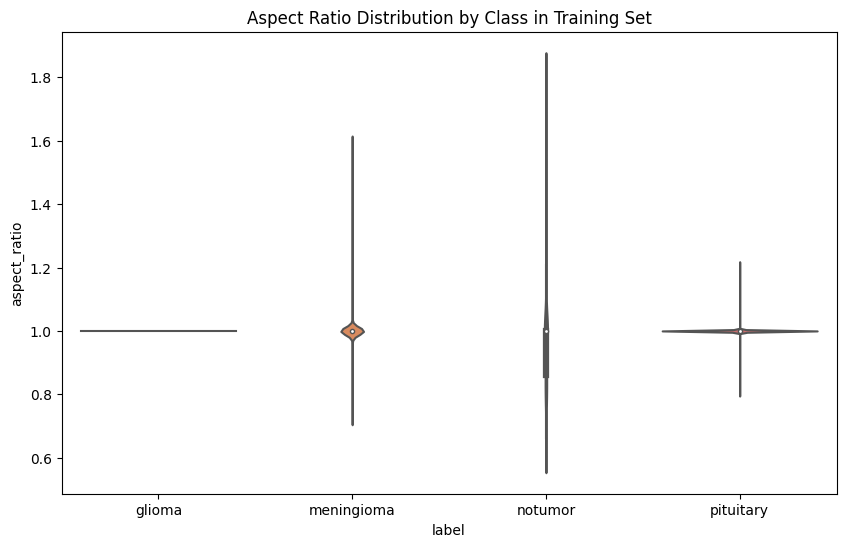

In [7]:
train_df['aspect_ratio'] = train_df['width'] / train_df['height']
test_df['aspect_ratio'] = test_df['width'] / test_df['height']

# Plot the aspect ratio distribution by class
plt.figure(figsize=(10, 6))
sns.violinplot(data=train_df, x="label", y="aspect_ratio", palette="muted")
plt.title("Aspect Ratio Distribution by Class in Training Set")
plt.show()

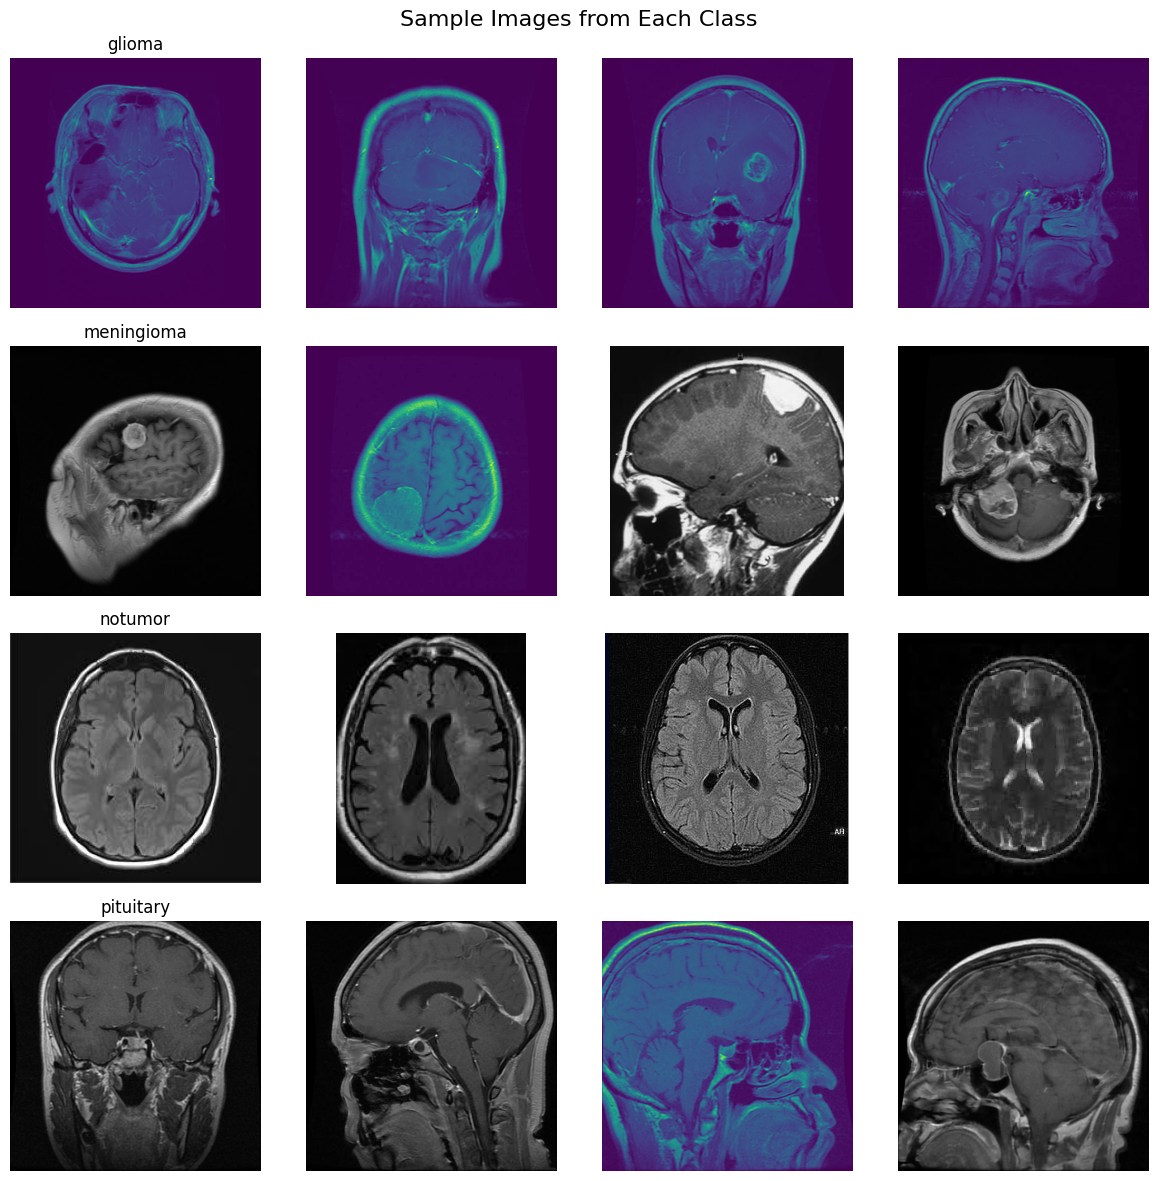

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, label in enumerate(classes):
    sample_images = train_df[train_df['label'] == label].sample(4)['image_path'].values
    for j, img_path in enumerate(sample_images):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(label, fontsize=12)
plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()


# Preprocessing

In [9]:
def resize_image(image_path, size=(224, 224)):
    image = Image.open(image_path)
    image = image.resize(size)
    return image


In [10]:
def normalize_image(image):
    image_array = np.array(image) / 255.0  # Normalize to [0, 1] range
    return image_array


In [11]:
# Set up ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize and fit label encoder on the labels
le = LabelEncoder()
train_df['label_encoded'] = le.fit_transform(train_df['label'])
test_df['label_encoded'] = le.transform(test_df['label'])


In [13]:
# Split training data into training and validation subsets
train_images, val_images, train_labels, val_labels = train_test_split(
    train_df['image_path'].values,
    train_df['label_encoded'].values,
    test_size=0.2,
    stratify=train_df['label_encoded'],
    random_state=42
)


In [14]:
def load_and_preprocess_image(path, label, size=(224, 224)):
    # Ensure `path` is a valid string
    path = tf.strings.regex_replace(path, '^b\'|\'$', '')  # Remove any b'' artifacts if they exist
    
    # Read the image file
    image = tf.io.read_file(path)
    # Decode the image
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize and normalize
    image = tf.image.resize(image, size)
    image = (image / 127.5) - 1  # Normalize to [-1, 1] range for compatibility with some models
    return image, label


# Outliner Removing

In [15]:
# Load and calculate image properties for each image in the dataset
def get_image_metrics(df):
    widths, heights, brightnesses = [], [], []
    for path in df['image_path']:
        img = Image.open(path)
        img_array = np.array(img)
        
        # Get dimensions
        width, height = img.size
        widths.append(width)
        heights.append(height)
        
        # Calculate brightness (mean pixel intensity)
        brightness = img_array.mean()
        brightnesses.append(brightness)
    
    # Add properties to DataFrame
    df['width'] = widths
    df['height'] = heights
    df['brightness'] = brightnesses
    return df

# Apply the function to training DataFrame
train_df = get_image_metrics(train_df)

# Calculate aspect ratio
train_df['aspect_ratio'] = train_df['width'] / train_df['height']

# Define function to identify outliers using IQR
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)].index

# Identify outliers for brightness, width, height, and aspect ratio
outliers_brightness = find_outliers(train_df, 'brightness')
outliers_width = find_outliers(train_df, 'width')
outliers_height = find_outliers(train_df, 'height')
outliers_aspect_ratio = find_outliers(train_df, 'aspect_ratio')

# Combine all outlier indices
all_outliers = set(outliers_brightness) | set(outliers_width) | set(outliers_height) | set(outliers_aspect_ratio)

# Drop the outliers from the DataFrame
train_df_cleaned = train_df.drop(index=all_outliers).reset_index(drop=True)
print(f"Removed {len(all_outliers)} outliers from training data.")


Removed 1713 outliers from training data.


In [16]:
# Ensure all image paths are valid strings
train_image_paths = [str(path) for path in train_images]
val_image_paths = [str(path) for path in val_images]

# Convert labels to tensors if not already done
train_labels = tf.convert_to_tensor(train_labels, dtype=tf.int32)
val_labels = tf.convert_to_tensor(val_labels, dtype=tf.int32)

# Define Dataset using the verified paths
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_labels))

# Map with the load_and_preprocess_image function
train_dataset = train_dataset.map(lambda x, y: load_and_preprocess_image(x, y))
val_dataset = val_dataset.map(lambda x, y: load_and_preprocess_image(x, y))

# Batch and shuffle the datasets
train_dataset = train_dataset.batch(32).shuffle(buffer_size=100)
val_dataset = val_dataset.batch(32)

# Model Building 

In [18]:
class VisionTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(VisionTransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)  # Pass 'training' here
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)  # Pass 'training' here
        return self.layernorm2(out1 + ffn_output)

def create_vit(input_shape=(224, 224, 3), patch_size=16, num_patches=196, embed_dim=128, num_heads=4, ff_dim=128, num_transformer_blocks=4):
    inputs = tf.keras.Input(shape=(num_patches, embed_dim))
    x = inputs

    # Stack transformer blocks
    for _ in range(num_transformer_blocks):
        x = VisionTransformerBlock(embed_dim, num_heads, ff_dim)(x, training=True)  # Pass 'training' here

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    return Model(inputs=inputs, outputs=x)


In [19]:
def create_hybrid_cnn_vit(input_shape=(224, 224, 3), num_classes=4, patch_size=16, embed_dim=128):
    # Step 1: Define CNN backbone
    cnn_model = create_cnn_backbone(input_shape=input_shape)
    cnn_output = cnn_model.output  # Extracted features from CNN

    # Step 2: Flatten and Dense layer to match the transformer input size
    cnn_flattened = layers.Flatten()(cnn_output)
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    patch_embedding = layers.Dense(embed_dim * num_patches)(cnn_flattened)
    patch_embedding = layers.Reshape((num_patches, embed_dim))(patch_embedding)  # Reshape to match ViT input

    # Step 3: Vision Transformer model
    vit_model = create_vit(input_shape=(num_patches, embed_dim))
    vit_output = vit_model(patch_embedding)

    # Step 4: Classification head
    outputs = Dense(num_classes, activation='softmax')(vit_output)
    return Model(inputs=cnn_model.input, outputs=outputs)


In [20]:
model = create_hybrid_cnn_vit()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=32
)


Epoch 1/20


I0000 00:00:1731294553.554373      83 service.cc:145] XLA service 0x7ebc0c001f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731294553.554466      83 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731294553.554473      83 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1731294570.966469     111 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_173', 288 bytes spill stores, 288 bytes spill loads

I0000 00:00:1731294572.486531     113 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_157', 256 bytes spill stores, 256 bytes spill loads

I0000 00:00:1731294574.237354     110 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_180', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:173129

 54/143 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.5026 - loss: 1.1294

I0000 00:00:1731294621.832476     173 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_163', 100 bytes spill stores, 100 bytes spill loads

I0000 00:00:1731294624.887803     171 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_173', 288 bytes spill stores, 288 bytes spill loads

I0000 00:00:1731294632.292827     171 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_157', 100 bytes spill stores, 100 bytes spill loads

I0000 00:00:1731294633.775446     172 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_180', 4 bytes spill stores, 4 bytes spill loads



 55/143 ━━━━━━━━━━━━━━━━━━━━ 1:14 852ms/step - accuracy: 0.5041 - loss: 1.1263

I0000 00:00:1731294646.491505      82 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_14', 40 bytes spill stores, 40 bytes spill loads



143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.5812 - loss: 0.9635

I0000 00:00:1731294672.486188     233 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_35', 100 bytes spill stores, 100 bytes spill loads

I0000 00:00:1731294672.913064     231 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_29', 100 bytes spill stores, 100 bytes spill loads

I0000 00:00:1731294673.805599     232 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_37', 288 bytes spill stores, 288 bytes spill loads



143/143 ━━━━━━━━━━━━━━━━━━━━ 145s 541ms/step - accuracy: 0.5818 - loss: 0.9622 - val_accuracy: 0.6955 - val_loss: 0.8381
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.7578 - loss: 0.5969 - val_accuracy: 0.7900 - val_loss: 0.5375
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.7957 - loss: 0.4922 - val_accuracy: 0.8276 - val_loss: 0.4333
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.8278 - loss: 0.4357 - val_accuracy: 0.8171 - val_loss: 0.4757
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.8216 - loss: 0.4422 - val_accuracy: 0.8259 - val_loss: 0.4218
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.8438 - loss: 0.3873 - val_accuracy: 0.8066 - val_loss: 0.4706
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 149ms/step - accuracy: 0.8322 - loss: 0.4053 - val_accuracy: 0.8600 - val_loss: 0.3584
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.8535 - loss: 0.3645 - va

In [22]:
# Predict on validation or test set
val_predictions = model.predict(val_dataset)
val_labels = [label.numpy() for _, label in val_dataset.unbatch()]

# Get the class with the highest probability
predicted_classes = tf.argmax(val_predictions, axis=1).numpy()

# Calculate F1-score
f1 = f1_score(val_labels, predicted_classes, average='weighted')
print(f"Validation F1-score: {f1:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step
Validation F1-score: 0.8976


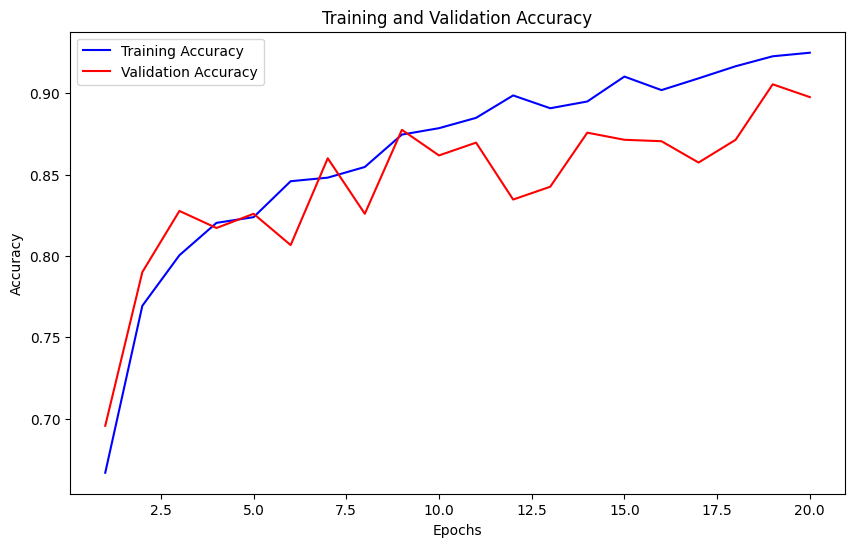

In [23]:
# Extract accuracy values for training and validation from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

# Plot the accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# ROC Curve

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step


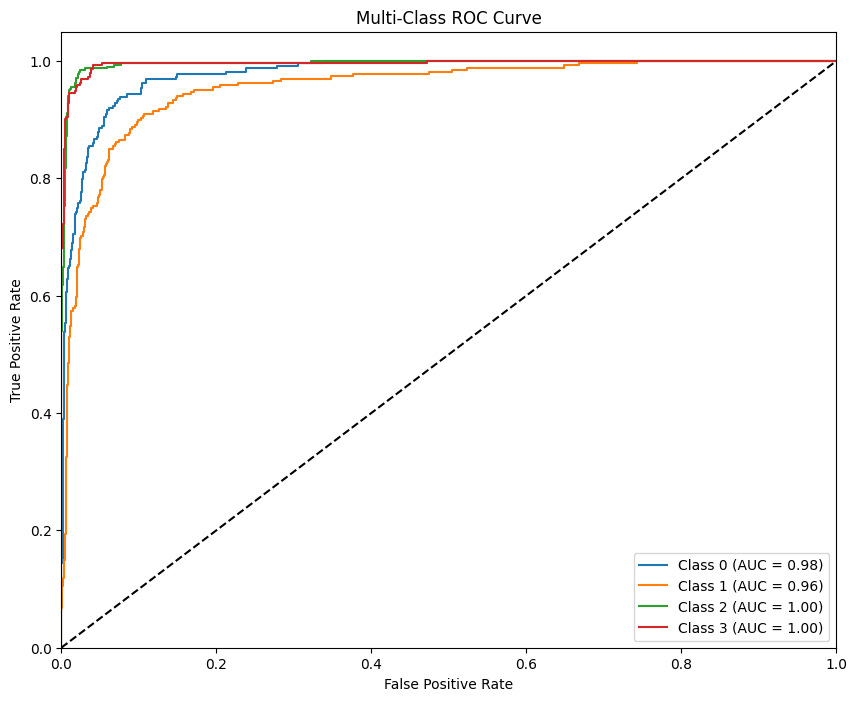

In [24]:
# Number of classes
num_classes = len(classes)

# Predict probabilities on validation data
val_predictions = model.predict(val_dataset)
val_labels = [label.numpy() for _, label in val_dataset.unbatch()]

# Binarize the labels for multi-class ROC
val_labels_binarized = label_binarize(val_labels, classes=range(num_classes))

# Plotting the ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(val_labels_binarized[:, i], val_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.show()


# Confusion Matrix

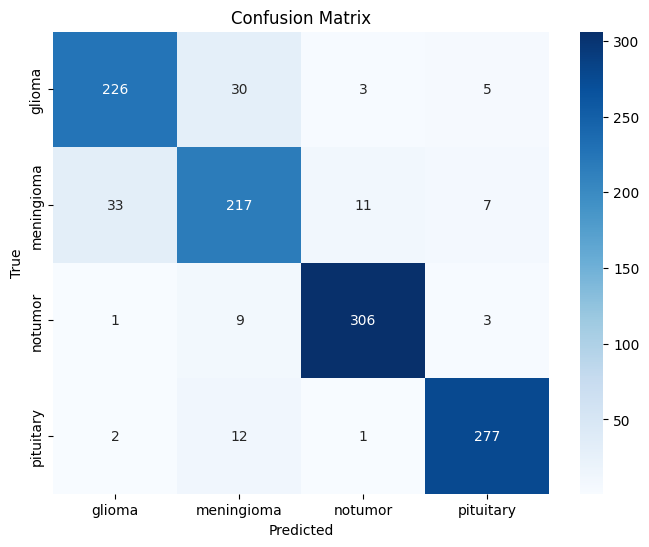

In [25]:
# Get predicted classes
predicted_classes = np.argmax(val_predictions, axis=1)

# Generate confusion matrix
cm = confusion_matrix(val_labels, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
